# `01_data_exploration.ipynb` — Updated Skeleton

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import os

df = pd.read_csv("../data/raw/nyc_taxi.csv")
print("Dataset shape:", df.shape)
df.head();
# Convert pickup_datetime to datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Create day_of_week column (0=Monday, 6=Sunday)
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek


Dataset shape: (1458644, 11)


## Basic Exploration

In [5]:
# Summary statistics
df.describe()

# Missing values
missing_counts = df.isnull().sum()
missing_counts

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
day_of_week           0
dtype: int64

## Visualizations

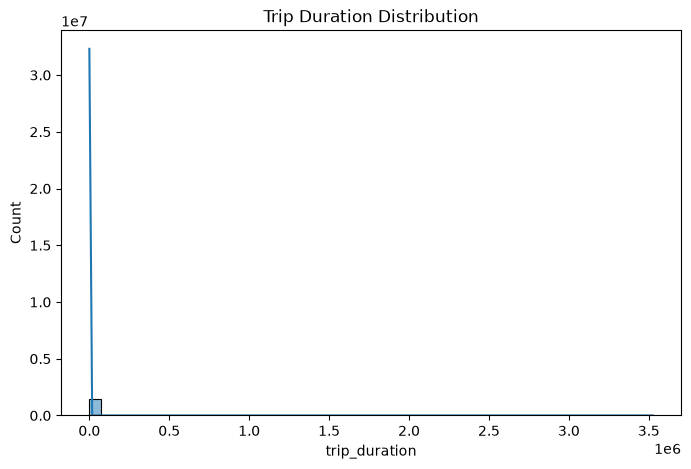

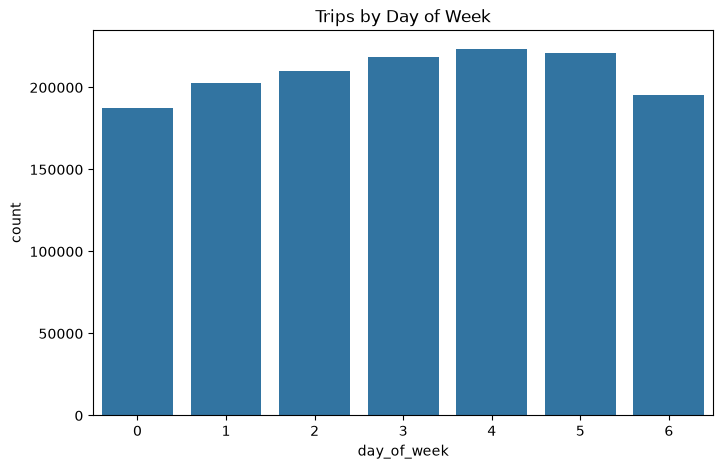

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title("Trip Duration Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='day_of_week', data=df)
plt.title("Trips by Day of Week")
plt.show()

## MLflow Integration

2026/08/23 18:42:00 INFO mlflow.tracking.fluent: Experiment with name 'EDA' does not exist. Creating a new experiment.


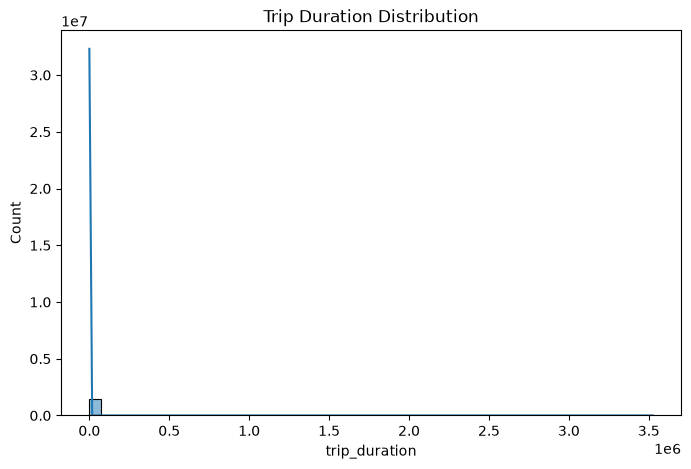

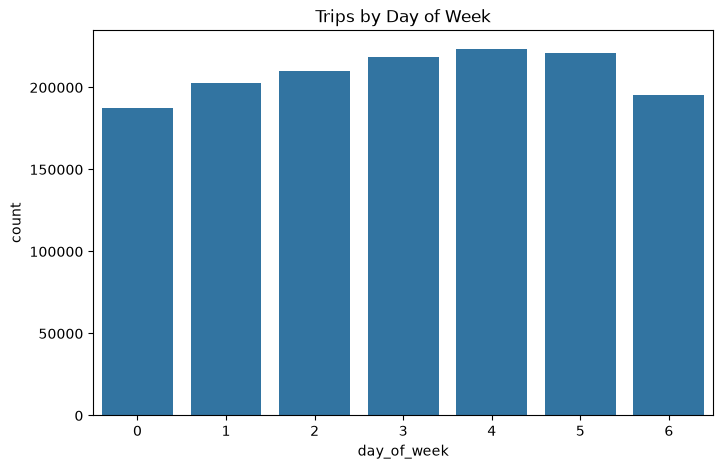

In [7]:
# Set MLflow tracking to SQLite backend
mlflow.set_tracking_uri("sqlite:///../logs/mlflow.db")
mlflow.set_experiment("EDA")

with mlflow.start_run(run_name="DataExploration"):
    # Save summary stats
    df.describe().to_csv("../logs/eda_summary.csv")
    mlflow.log_artifact("../logs/eda_summary.csv", artifact_path="eda")

    # Save missing values report
    missing_counts.to_csv("../logs/missing_values.csv")
    mlflow.log_artifact("../logs/missing_values.csv", artifact_path="eda")

    # Save plots
    plt.figure(figsize=(8,5))
    sns.histplot(df['trip_duration'], bins=50, kde=True)
    plt.title("Trip Duration Distribution")
    plot_path = "../logs/trip_duration_dist.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path, artifact_path="plots")

    plt.figure(figsize=(8,5))
    sns.countplot(x='day_of_week', data=df)
    plt.title("Trips by Day of Week")
    plot_path = "../logs/trips_by_day.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path, artifact_path="plots")


### What This Notebook Now Does
• Explores raw dataset (shape, summary, missing values).

• Visualizes distributions and categorical breakdowns.

• Logs EDA artifacts (summary stats, missing values, plots) into MLflow.

• Keeps everything consistent with your pipeline (train_model.py + main.py).
